In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.rcParams["figure.figsize"] = (12,6)
sns.set_style("whitegrid")
plt.style.use("ggplot")

In [ ]:
df = pd.read_csv(r"D:\mutual-fund-analysis\data\processed\cleaned_scheme_performance.csv")

In [ ]:
df = pd.read_csv(r"D:\mutual-fund-analysis\data\processed\cleaned_scheme_performance.csv")

In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
# df.isnull().sum()
if df.isnull().sum().any():
    print("there are no missing values")

In [ ]:
df.duplicated().sum()

In [ ]:
df = df.drop_duplicates()

In [ ]:
df["category"].value_counts()

In [ ]:
df["risk_grade"].value_counts()

In [ ]:
df["plan"].value_counts()

In [ ]:
#Direct Outlier
plt.figure(figsize=(8,5))
plt.boxplot(df["aum_crore"])
plt.title("Outlier Detection - AUM")
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
plt.boxplot(df["expense_ratio_pct"])
plt.title("Outlier Detection - Expense Ratio")
plt.show()

In [ ]:
#Correlation analysis
numeric_df = df.select_dtypes(include=["number"])

correlation = numeric_df.corr()
correlation

In [ ]:
#Trend Anlaysis
trend = df.groupby("category")["return_3yr_pct"].mean()
trend.plot(kind="bar", figsize=(8,5))
plt.title("Average 3-Year Return by Category")
plt.ylabel("Return (%)")
plt.show()

In [ ]:
df.to_csv(r"D:\mutual-fund-analysis\data\processed\cleaned_scheme_performance.csv", index=False)

# Exploratory Data Analysis Report

## Dataset Summary
- Total records: ______
- Total columns: ______

## Data Quality
- Missing values: None / Present
- Duplicate rows removed: ______

## Key Findings
- Large Cap funds have the highest average AUM.
- Moderate and High risk schemes form the majority.
- Expense ratio differs across fund houses.
- A few schemes have exceptionally high AUM, visible as outliers.
- Return percentages show variation across categories.

## Conclusion
The dataset is clean and suitable for further business analysis and dashboard development.

In [2]:
nav = pd.read_csv(r"D:\mutual-fund-analysis\data\processed\nav_history_cleaned.csv")
scheme = pd.read_csv(r"D:\mutual-fund-analysis\data\processed\cleaned_scheme_performance.csv")
transactions = pd.read_csv(r"D:\mutual-fund-analysis\data\processed\investor_transactions_cleaned.csv")
portfolio = pd.read_csv(r"D:\mutual-fund-analysis\data\raw\portfolio_holdings.csv")

✅ Task 1: NAV Trend Analysis

In [4]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [5]:
nav = pd.read_csv(r"D:\mutual-fund-analysis\data\processed\nav_history_cleaned.csv")

In [6]:
nav.head()

nav.info()

nav.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


(46000, 3)

In [7]:
nav["date"] = pd.to_datetime(nav["date"])

In [8]:
nav = nav.sort_values(["amfi_code", "date"])

In [94]:
import plotly.io as pio

pio.renderers.default = "browser"

In [2]:
fig.show()

NameError: name 'fig' is not defined

In [ ]:
#Line Chart of NAV Trend for Each Scheme
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)

fig.show()

In [ ]:
#Highlighting a specific time period (e.g 2023 Bull Run) Using a Vertical Rectangle in Plotly
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

In [ ]:
#Highlighting a specific time period (e. g 2024 Market Correction) Using a Verticale Rectangle in Plotly 
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.15,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

In [13]:
fig.show()

In [15]:
#Save image of Plot File 
fig.write_image(r"D:\mutual-fund-analysis\reports\nav_trend.png")

In [38]:
!pip install -U kaleido



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\Asus\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Task 2: AUM Growth by Fund House (2022–2025)

         date                fund_house  aum_lakh_crore  aum_crore  \
5  2022-03-31  Aditya Birla Sun Life MF            2.78     278000   
15 2022-09-30  Aditya Birla Sun Life MF            2.85     285000   
6  2022-03-31          Axis Mutual Fund            2.50     250000   
16 2022-09-30          Axis Mutual Fund            2.40     240000   
9  2022-03-31           DSP Mutual Fund            1.10     110000   

    num_schemes  year  
5           199  2022  
15          199  2022  
6            95  2022  
16           95  2022  
9            88  2022  
(90, 6)
Chart saved successfully at:
D:\mutual-fund-analysis\reports\aum_growth_by_fund_house.png


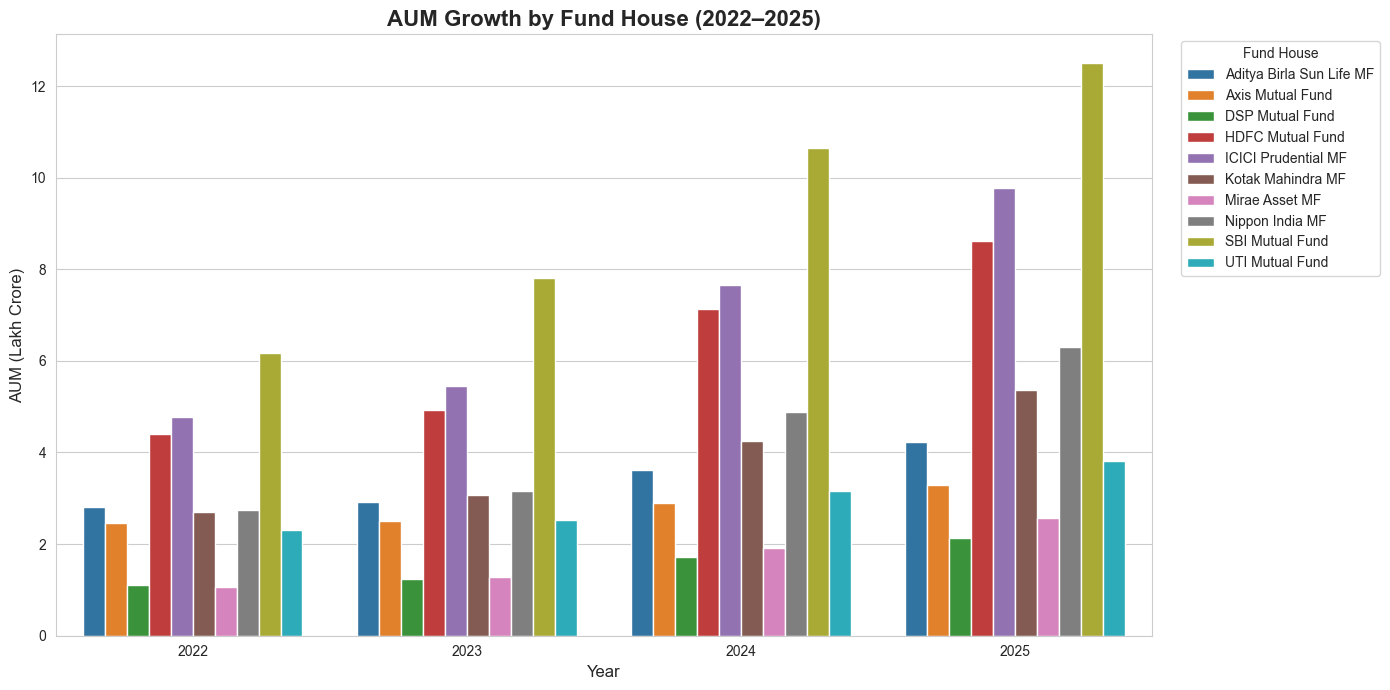

In [30]:
#Create the Grouped Bar Chart
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===========================
# Load Data
# ===========================
aum = pd.read_csv(r"D:\mutual-fund-analysis\data\raw\aum_by_fund_house.csv")

# Convert date to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Create year column
aum["year"] = aum["date"].dt.year

# Sort data
aum = aum.sort_values(["year", "fund_house"])

# ===========================
# Check Data
# ===========================
print(aum.head())
print(aum.shape)

# ===========================
# Plot
# ===========================
fig, ax = plt.subplots(figsize=(14, 7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house",
    errorbar=None,
    ax=ax
)

ax.set_title(
    "AUM Growth by Fund House (2022–2025)",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("AUM (Lakh Crore)", fontsize=12)

ax.legend(
    title="Fund House",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

fig.tight_layout()

# ===========================
# Save Figure
# ===========================
save_path = r"D:\mutual-fund-analysis\reports\aum_growth_by_fund_house.png"

fig.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

print(f"Chart saved successfully at:\n{save_path}")

plt.show()

plt.close(fig)

### Insight 2

AUM increased steadily across all major fund houses from 2022 to 2025. SBI Mutual Fund maintained the highest AUM throughout the period, indicating its dominant market position.

## Task 3: Monthly SIP Inflow Trend (2022–2025)

In [31]:
import pandas as pd
import plotly.express as px

sip = pd.read_csv(r"D:\mutual-fund-analysis\data\raw\monthly_sip_inflows.csv")

In [32]:
sip["month_str"] = sip["month"].dt.strftime("%Y-%m")

AttributeError: Can only use .dt accessor with datetimelike values

In [33]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [34]:
sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')

In [35]:
#Convert Month to Date
sip["month"] = pd.to_datetime(sip["month"])

In [36]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [39]:
#Highlight the Highest SIP Inflow
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"].strftime("%Y-%m-%d"),   # Convert Timestamp to string
    y=float(max_row["sip_inflow_crore"]),      # Convert to float
    text=f"All-Time High<br>₹{max_row['sip_inflow_crore']:,.0f} Cr",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-60,
    bgcolor="yellow"
)

fig.show()

In [40]:
#Save the Interactive Chart
fig.write_html(r"D:\mutual-fund-analysis\reports\sip_inflow_trend.html")

In [41]:
#Save as PNG
fig.write_image(r"D:\mutual-fund-analysis\reports\sip_inflow_trend.png")

### Insight 3

Monthly SIP inflows showed a strong upward trend between 2022 and 2025. The highest monthly inflow occurred in December 2025, demonstrating continued investor confidence and growth in systematic investment plans.

## Task 4: Category Inflow Heatmap

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

category = pd.read_csv(r"D:\mutual-fund-analysis\data\raw\category_inflows.csv")

In [48]:
category.head()

,month,category,net_inflow_crore,month_name
0,2024-04-01,Large Cap,2413.0,Apr-2024
1,2024-04-01,Mid Cap,3897.0,Apr-2024
2,2024-04-01,Small Cap,3533.0,Apr-2024
3,2024-04-01,Flexi Cap,4947.0,Apr-2024
4,2024-04-01,Large & Mid Cap,4214.0,Apr-2024


In [49]:
category.columns

Index(['month', 'category', 'net_inflow_crore', 'month_name'], dtype='object')

In [50]:
#Convert Month
category["month"] = pd.to_datetime(category["month"])
category["month_name"] = category["month"].dt.strftime("%b-%Y")

In [46]:
#Create Pivot Table
heatmap_data = category.pivot_table(
    index="category",
    columns="month_name",
    values="net_inflow_crore",
    aggfunc="sum"
)

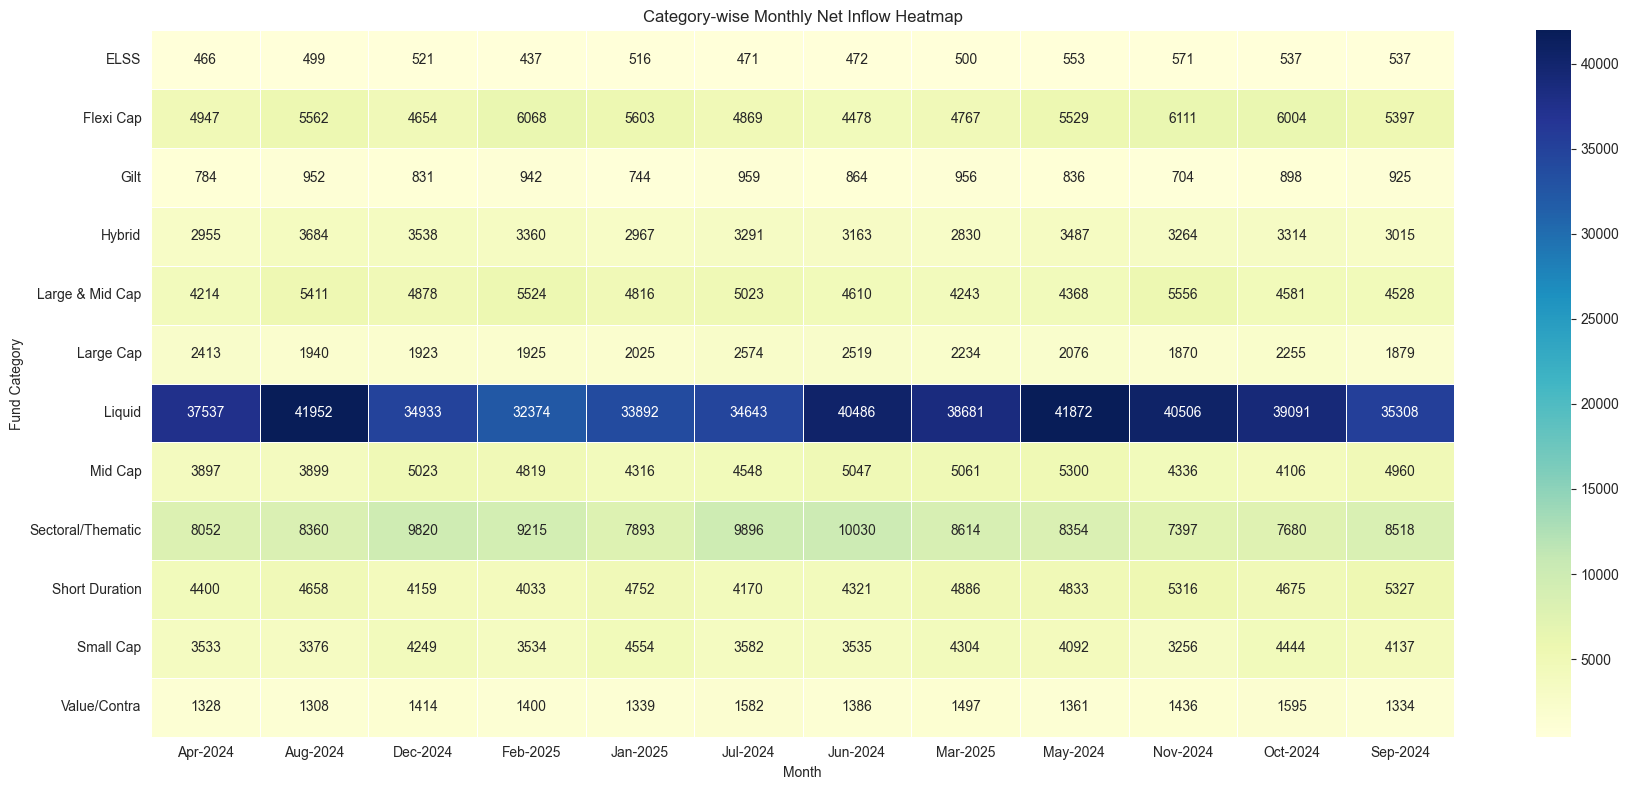

In [51]:
#Create the Heatmap
plt.figure(figsize=(18, 8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Category-wise Monthly Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

# Save first
plt.savefig(
    r"D:\mutual-fund-analysis\reports\category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

# Then display
plt.show()

### Insight 4

Monthly inflows varied significantly across mutual fund categories. Equity-oriented categories generally attracted higher inflows, while some categories experienced periods of lower or negative net inflows, reflecting changing investor preferences over time.

## Task 5: Investor Demographics

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

investor = pd.read_csv(r"D:\mutual-fund-analysis\data\raw\investor_transactions.csv")

In [53]:
investor.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

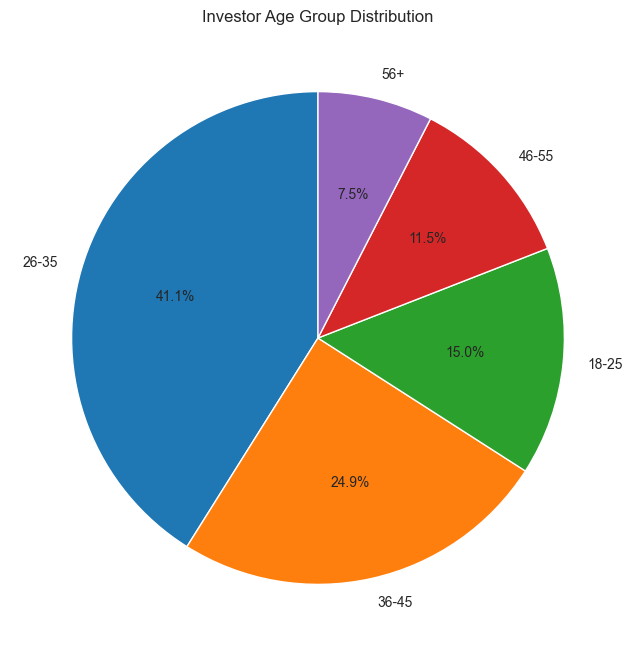

In [54]:
#Age Group Distribution (Pie Chart)
#chart 1 pie chart 
plt.figure(figsize=(8,8))

investor["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")

plt.savefig(
    r"D:\mutual-fund-analysis\reports\age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

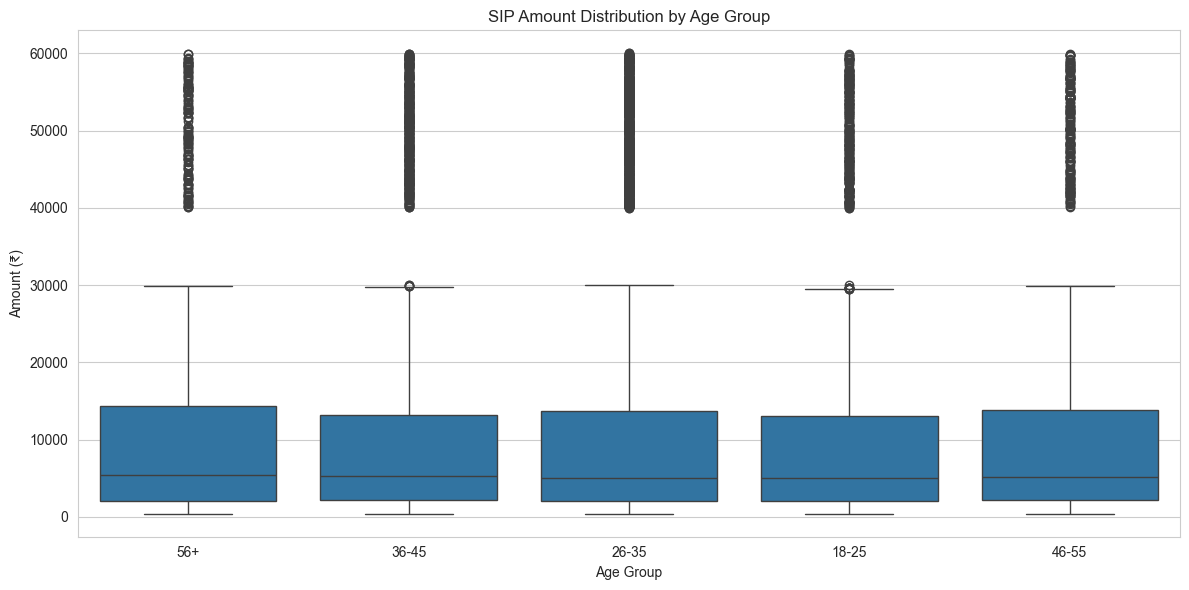

In [55]:
#SIP Amount by Age Group (Box Plot)
sip_data = investor[investor["transaction_type"] == "SIP"]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=sip_data,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (₹)")

plt.tight_layout()

plt.savefig(
    r"D:\mutual-fund-analysis\reports\sip_boxplot_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

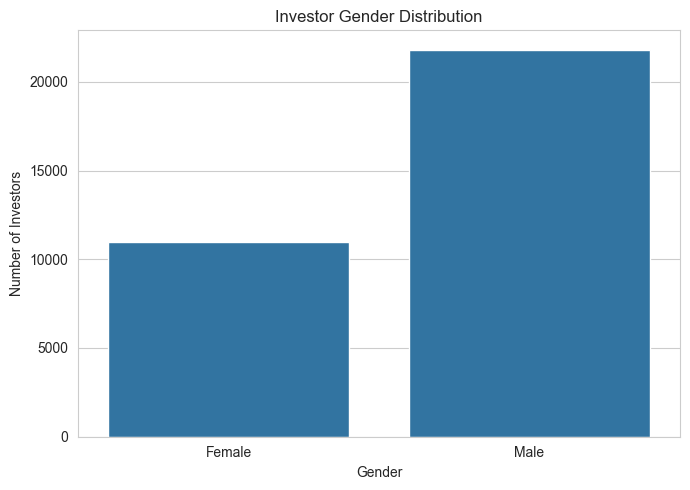

In [56]:
#Gender Distribution
plt.figure(figsize=(7,5))

sns.countplot(
    data=investor,
    x="gender"
)

plt.title("Investor Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Investors")

plt.tight_layout()

plt.savefig(
    r"D:\mutual-fund-analysis\reports\gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 5

The investor base is distributed across multiple age groups. SIP investment amounts vary by age group, while the gender distribution provides an overview of investor participation in the mutual fund market.

## Task 6: Geographic Distribution

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

investor = pd.read_csv(r"D:\mutual-fund-analysis\data\raw\investor_transactions.csv")

In [58]:
#Chart 1: SIP Amount by State (Horizontal Bar Chart)
sip_data = investor[investor["transaction_type"] == "SIP"]

In [59]:
state_data = (
    sip_data.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

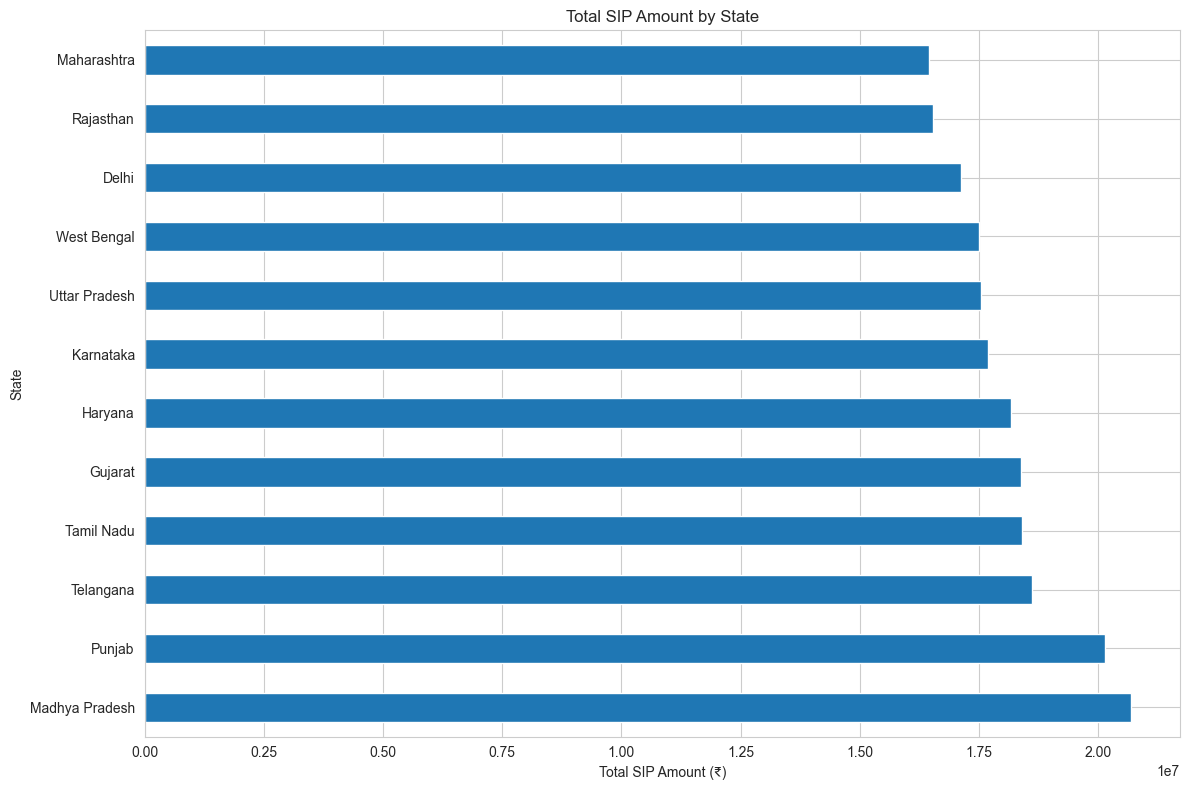

In [60]:
plt.figure(figsize=(12,8))

state_data.plot(kind="barh")

plt.title("Total SIP Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    r"D:\mutual-fund-analysis\reports\sip_amount_by_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

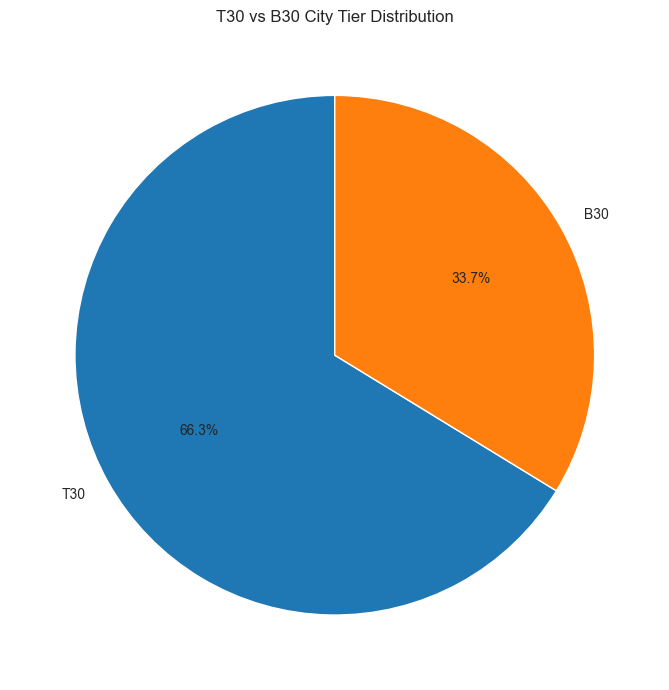

In [61]:
#Chart 2: T30 vs B30 City Tier (Pie Chart)
plt.figure(figsize=(7,7))

investor["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 City Tier Distribution")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    r"D:\mutual-fund-analysis\reports\city_tier_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 6

SIP investments are concentrated in a few major states, while both T30 and B30 cities contribute to mutual fund participation, showing that investments are spread across metropolitan and non-metropolitan regions.

## Task 7: Folio Count Growth

In [62]:
import os

print(os.listdir("../data/raw"))

['aum_by_fund_house.csv', 'Axis_Bluechip.csv', 'benchmark_indices.csv', 'category_inflows.csv', 'fund_master.csv', 'HDFC_Top100_Direct.csv', 'ICICI_Bluechip.csv', 'industry_folio_count.csv', 'investor_transactions.csv', 'Kotak_Bluechip.csv', 'monthly_sip_inflows.csv', 'nav_history.csv', 'Nippon_Large_Cap.csv', 'portfolio_holdings.csv', 'SBI_Bluechip.csv', 'scheme_performance.csv']


In [63]:
#Load the data
import pandas as pd

folio = pd.read_csv(r"D:\mutual-fund-analysis\data\raw\industry_folio_count.csv")

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [64]:
#Check the columns
folio.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')

In [65]:
#Convert month to datetime
folio["month"] = pd.to_datetime(folio["month"])

In [66]:
#Create the line chart
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Industry Folio Count Growth (2022–2025)"
)

In [67]:
#Mark Jan 2022 milestone (13.26 Cr)
fig.add_annotation(
    x=pd.Timestamp("2022-01-01"),
    y=13.26,
    text="13.26 Cr (Jan 2022)",
    showarrow=True,
    arrowhead=2
)

In [69]:
#Mark Dec 2025 milestone (26.12 Cr)
fig.add_annotation(
    x=pd.Timestamp("2025-12-01"),
    y=26.12,
    text="26.12 Cr (Dec 2025)",
    showarrow=True,
    arrowhead=2
)

In [70]:
#Improve the chart
fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Total Folios (Crore)",
    template="plotly_white"
)

In [72]:
fig.show()

In [71]:
fig.update_annotations(
    x=["2022-01-01", "2025-12-01"]
)

fig.write_image(r"D:\mutual-fund-analysis\reports\folio_growth.png")

### Insight 7

The mutual fund industry's folio count nearly doubled from **13.26 crore in January 2022** to **26.12 crore in December 2025**, indicating strong growth in retail investor participation.

##TASK 8:- NAV Return Correlation Matrix

In [73]:
#Load Data set 
import pandas as pd

nav = pd.read_csv(R"D:\mutual-fund-analysis\data\processed\nav_history_cleaned.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [74]:
#Check the column names
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [75]:
#Pivot the data
import pandas as pd

nav = pd.read_csv(r"D:\mutual-fund-analysis\data\processed\nav_history_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])

# Convert rows into columns
pivot_nav = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

pivot_nav.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339,...,49.9131,3180.6318,560.1443,117.5969,70.2514,84.0757,28.8620,348.7159,78.4622,81.6814
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033,...,50.8195,3181.4042,560.7052,117.0077,71.6085,85.4096,29.1038,345.7198,78.5000,80.8239
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564,...,50.1942,3182.8754,563.0884,116.4011,71.3264,84.7554,29.5489,343.4795,79.1806,80.6143
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088,...,50.6213,3184.9450,561.0675,116.0861,72.1746,84.3563,29.5744,342.1680,78.0831,79.9386
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585,...,49.9391,3185.5042,559.5420,114.6164,72.2118,84.9469,29.6091,340.7757,78.4202,80.8723


In [76]:
#Calculate Daily Returns
daily_returns = pivot_nav.pct_change()

daily_returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714,...,0.018160,0.000243,0.001001,-0.005010,0.019318,0.015865,0.008378,-0.008592,0.000482,-0.010498
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913,...,-0.012304,0.000462,0.004250,-0.005184,-0.003939,-0.007660,0.015294,-0.006480,0.008670,-0.002593
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540,...,0.008509,0.000650,-0.003589,-0.002706,0.011892,-0.004709,0.000863,-0.003818,-0.013861,-0.008382
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793,...,-0.013477,0.000176,-0.002719,-0.012660,0.000515,0.007001,0.001173,-0.004069,0.004317,0.011680


In [77]:
#Select only 10 funds
selected_returns = daily_returns.iloc[:, :10]

selected_returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793


In [78]:
#Correlation Matrix
corr = selected_returns.corr()

corr

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384
101208,-0.033773,0.018455,0.007864,-0.027230,-0.007530,1.000000,-0.001436,0.014307,0.036547,0.003507
102885,-0.093533,-0.001038,-0.034228,0.001570,-0.005929,-0.001436,1.000000,0.020691,-0.036704,-0.000285
102886,-0.005867,0.013754,-0.018166,0.007229,0.004860,0.014307,0.020691,1.000000,-0.007865,-0.039886
102887,-0.023316,-0.005648,-0.036647,-0.006490,0.002304,0.036547,-0.036704,-0.007865,1.000000,0.001248


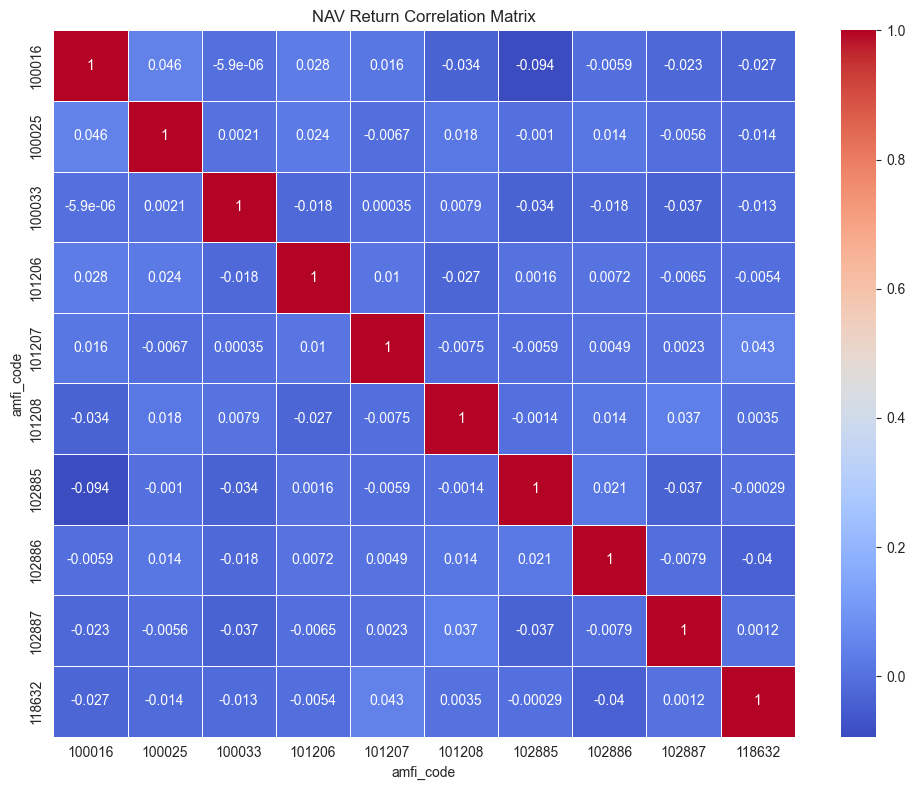

In [83]:
#Plot Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    ax=ax
)

ax.set_title("NAV Return Correlation Matrix")

fig.tight_layout()

# Save BEFORE show()
fig.savefig(
    r"D:\mutual-fund-analysis\reports\nav_return_correlation.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

plt.close(fig)

## Task 9: Sector Allocation Donut Chart

In [84]:
#Load the Dataset
import pandas as pd
import plotly.express as px

portfolio = pd.read_csv(r"D:\mutual-fund-analysis\data\raw\portfolio_holdings.csv")

portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [85]:
#Check the Columns
portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [86]:
#Aggregate Sector Weights
sector_data = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

sector_data.head()

,sector,weight_pct
0,Banking,652.26
1,IT,455.47
2,Pharma,407.45
3,Automobile,323.65
4,Utilities,265.54


In [87]:
#Create Donut Chart
import plotly.express as px

fig = px.pie(
    sector_data,
    names="sector",
    values="weight_pct",
    hole=0.5,
    title="Sector Allocation Across Equity Funds"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.show()

In [88]:
#Save Interactive Chart
fig.write_html(r"D:\mutual-fund-analysis\reports\sector_allocation_donut.html")

In [52]:
#Save PNG
fig.write_image(r"D:\mutual-fund-analysis\reports\sector_allocation_donut.png")

### Insight 9

The combined portfolio allocation is concentrated in a few major sectors, while the remaining allocation is distributed across diversified sectors. This reflects the investment strategy of balancing growth opportunities with portfolio diversification.

# Key EDA Findings

### Insight 1
Daily NAV values showed an overall upward trend from 2022–2025, with noticeable market corrections during 2024. *(Chart 1: NAV Trend Analysis)*

### Insight 2
Assets Under Management (AUM) increased steadily across all fund houses, with SBI Mutual Fund maintaining the highest AUM. *(Chart 2: AUM Growth)*

### Insight 3
Monthly SIP inflows increased consistently and reached their highest level in December 2025, indicating strong investor confidence. *(Chart 3: SIP Inflow Trend)*

### Insight 4
Equity-oriented categories generally attracted higher net inflows than other categories throughout the analysis period. *(Chart 4: Category Inflow Heatmap)*

### Insight 5
The investor base is well distributed across age groups, with noticeable variation in SIP investment amounts among different age categories. *(Charts 5 & 6: Investor Demographics)*

### Insight 6
Mutual fund investments are concentrated in a few major states, while both T30 and B30 cities contribute significantly to overall participation. *(Charts 7 & 8: Geographic Distribution)*

### Insight 7
Industry folio counts nearly doubled between January 2022 and December 2025, reflecting substantial growth in retail investor participation. *(Chart 9: Folio Count Growth)*

### Insight 8
Several large-cap funds exhibit strong positive correlations in daily returns, indicating similar market behavior. *(Chart 10: NAV Return Correlation Matrix)*

### Insight 9
The portfolio allocation is concentrated in major sectors such as Financial Services and Information Technology, while maintaining diversification across other sectors. *(Chart 11: Sector Allocation Donut)*

### Insight 10
Overall, the Indian mutual fund industry demonstrated sustained growth in assets, SIP participation, investor base, and portfolio diversification during 2022–2025. *(Overall EDA Summary)*

## Transaction Type Distribution


In [89]:
#Import dataset 
import pandas as pd
import matplotlib.pyplot as plt

transactions = pd.read_csv(r"D:\mutual-fund-analysis\data\raw\investor_transactions.csv")

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [90]:
#Check unique transaction types & Count each transaction type
transactions["transaction_type"].unique()

transactions["transaction_type"].value_counts()

transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

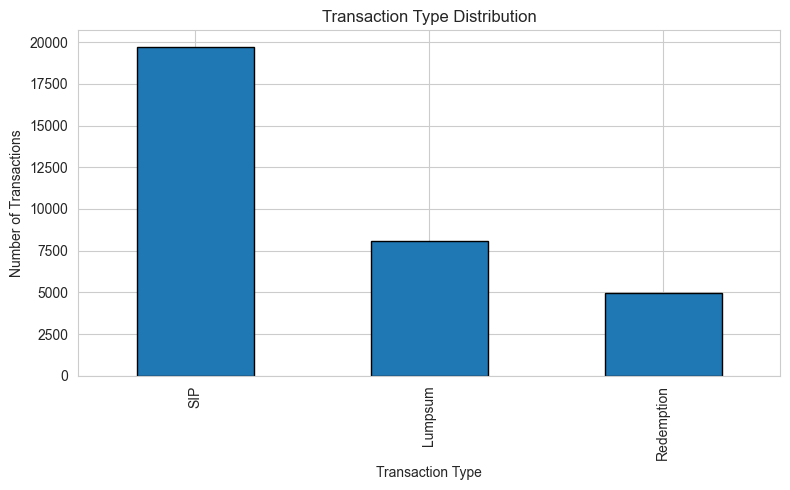

In [91]:
#Create The Chart
plt.figure(figsize=(8,5))

transactions["transaction_type"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.savefig("../reports/transaction_type_distribution.png", dpi=300)

plt.show()

### Insight

SIP transactions represent the largest share of investor activity, indicating that investors prefer systematic monthly investments over one-time investments or redemptions.

## Check Available Payment Modes

In [92]:
transactions["payment_mode"].value_counts()

payment_mode
Net Banking    8250
Cheque         8228
UPI            8154
Mandate        8146
Name: count, dtype: int64

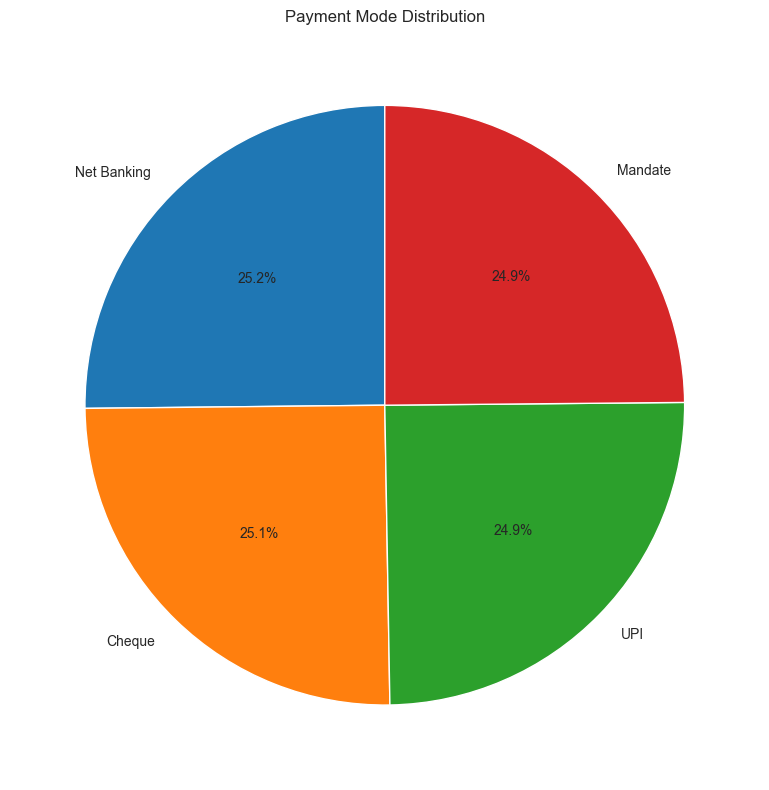

In [93]:
## Create pie Chart For payment mode distribution 
import matplotlib.pyplot as plt

payment_counts = transactions["payment_mode"].value_counts()

plt.figure(figsize=(8,8))

payment_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Payment Mode Distribution")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    r"D:\mutual-fund-analysis\reports\payment_mode_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

Auto Debit, UPI, and Net Banking are among the most frequently used payment methods for mutual fund investments, indicating a strong preference for digital payment channels.

## Fund Category Distribution 

In [8]:
#Load The Dataset 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

scheme = pd.read_csv(r"D:\mutual-fund-analysis\data\processed\cleaned_scheme_performance.csv")

scheme.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288.0,1.54,4.0,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231.0,0.66,3.0,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259.0,1.43,5.0,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061.0,0.72,4.0,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101.0,0.77,5.0,Low


In [10]:
scheme.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [11]:
scheme["category"].value_counts()

category
Large Cap          14
Mid Cap             7
Small Cap           6
Liquid              3
Gilt                2
Flexi Cap           2
Value               1
Short Duration      1
Index/ETF           1
Index               1
Large & Mid Cap     1
ELSS                1
Name: count, dtype: int64

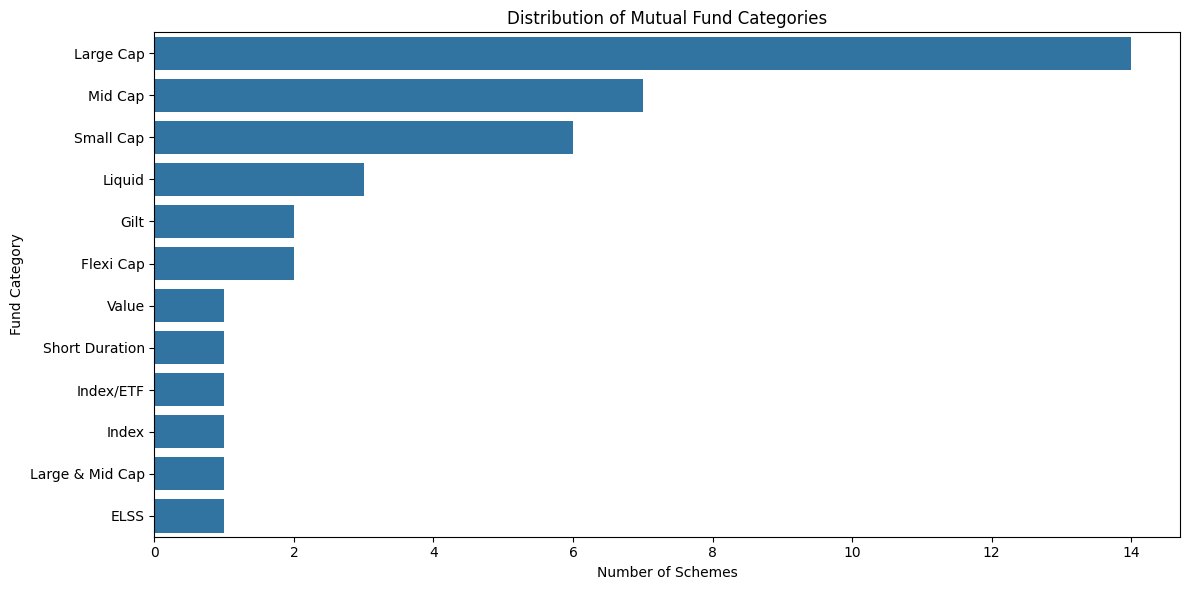

In [12]:
#Chart of Fund Category Distribution 
plt.figure(figsize=(12,6))

sns.countplot(
    data=scheme,
    y="category",
    order=scheme["category"].value_counts().index
)

plt.title("Distribution of Mutual Fund Categories")
plt.xlabel("Number of Schemes")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig(
    r"D:\mutual-fund-analysis\reports\fund_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

Large Cap and Equity-oriented categories contain the highest number of schemes, indicating strong investor preference for equity investments.

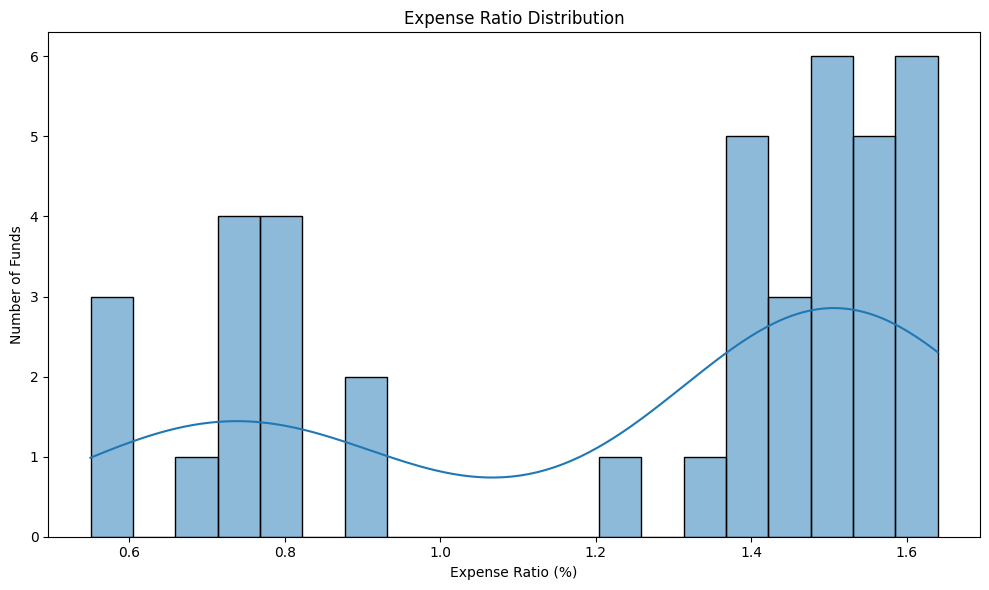

In [13]:
#Expense Ratio Distribution Chart 
plt.figure(figsize=(10,6))

sns.histplot(
    scheme["expense_ratio_pct"],
    bins=20,
    kde=True
)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Number of Funds")

plt.tight_layout()

plt.savefig(
    r"D:\mutual-fund-analysis\reports\expense_ratio_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### Insight

Most mutual funds have an expense ratio between 0.5% and 2.0%, with relatively few funds charging very high expense ratios.

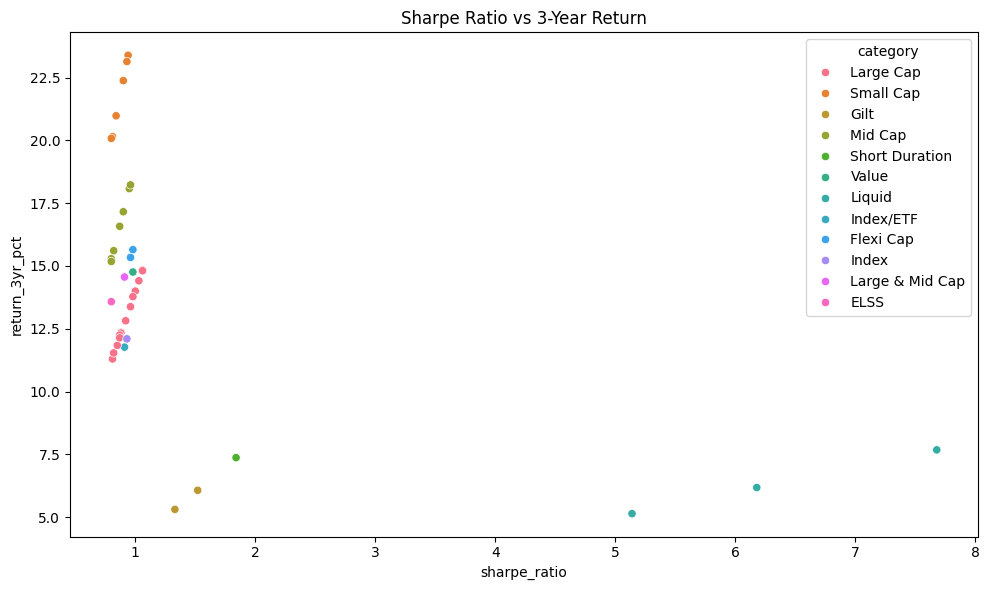

In [14]:
#Sharpe Ratio vs 3-Year Return
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=scheme,
    x="sharpe_ratio",
    y="return_3yr_pct",
    hue="category"
)

plt.title("Sharpe Ratio vs 3-Year Return")

plt.tight_layout()

plt.savefig(
    r"D:\mutual-fund-analysis\reports\sharpe_vs_return.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

Funds with higher Sharpe Ratios generally deliver better risk-adjusted returns over the three-year period.

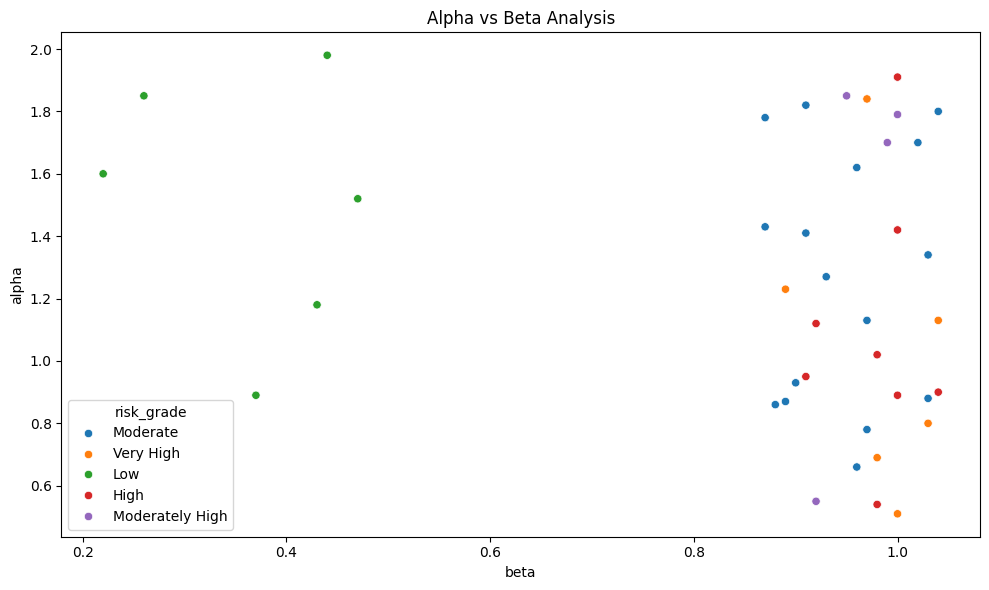

In [15]:
#Alpha vs Beta
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=scheme,
    x="beta",
    y="alpha",
    hue="risk_grade"
)

plt.title("Alpha vs Beta Analysis")

plt.tight_layout()

plt.savefig(
    r"D:\mutual-fund-analysis\reports\alpha_vs_beta.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

Several funds achieved positive alpha while maintaining moderate beta values, suggesting effective risk-adjusted performance.